 # Bitcoin Price Prediction


La variable objetivo es el **retorno logarítmico del precio Close**. Esta transformación garantiza estacionariedad en la serie, como se demostró en el EDA mediante el test ADF.

## Setup y carga de datos

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

# Modelos
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Preprocesamiento y validación
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# Tests estadísticos
from statsmodels.tsa.stattools import bds
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Importación hiperparametros
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
# LIME
import lime
import lime.lime_tabular


In [2]:
# Carga y preprocesamiento de datos 
datos = pd.read_csv('data.csv')
datos['TimestampConventional'] = pd.to_datetime(datos['Timestamp'], unit='s')
datos.set_index('TimestampConventional', inplace=True)

df = datos['2019':][["Open","High","Low","Close","Volume"]].resample('15min').mean()
df = df.dropna()

print(f'Datos cargados: {df.shape[0]:,} observaciones')
print(f'Periodo: {df.index[0]} → {df.index[-1]}')

Datos cargados: 250,581 observaciones
Periodo: 2019-01-01 00:00:00 → 2026-02-24 00:00:00


El dataset queda con 250.581 observaciones y en el periodo del 2019-01-01 hasta el 2026-02-24

## Construcción de features

La variable objetivo es el **retorno logarítmico del Close**. Como el EDA mostró que 7 lags captura la memoria relevante de la serie (menor RMSE y residuos independientes según BDS), se usan **7 lags** como features de entrada.

Serie de retornos: 250,580 observaciones
Media: 0.000011 | Std: 0.002869


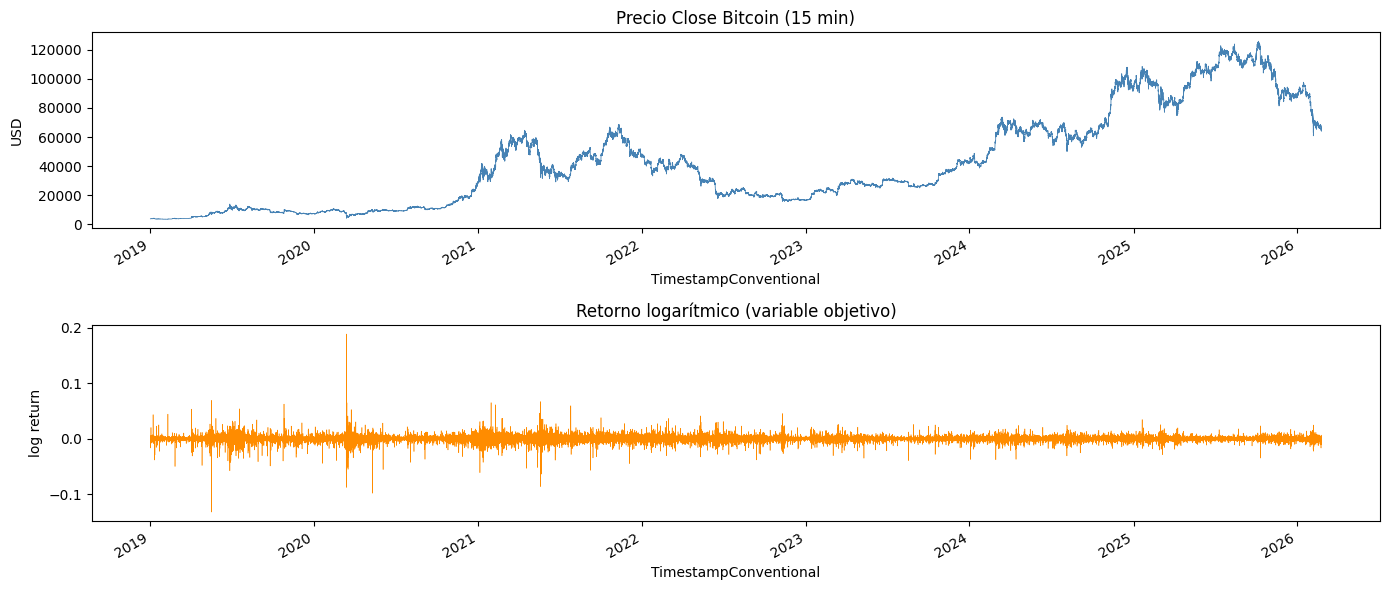

In [3]:
# Retorno logarítmico
log_return = np.log(df['Close']).diff().dropna()

# Parámetros del problema
N_LAGS     = 7   # inputs: 7 pasos previos
N_STEPS    = 1   # output: predecir 1 paso adelante
N_JUMP     = 1   # salto en cada muestra
RANDOM_SEED = 42

print(f'Serie de retornos: {len(log_return):,} observaciones')
print(f'Media: {log_return.mean():.6f} | Std: {log_return.std():.6f}')

# Visualización rápida
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
df['Close'].plot(ax=axes[0], color='steelblue', linewidth=0.6)
axes[0].set_title('Precio Close Bitcoin (15 min)')
axes[0].set_ylabel('USD')

log_return.plot(ax=axes[1], color='darkorange', linewidth=0.4)
axes[1].set_title('Retorno logarítmico (variable objetivo)')
axes[1].set_ylabel('log return')

plt.tight_layout()
plt.show()

La media de 0.000011 la cual es practicamente cero confirman que el Bitcoin no sube ni baja de forma consistente cada 15 minutos. Se puede observar en la grafica de abajo oscila consistentemente alredodr de 0 a lo largo de todo el periodo de tiempo excepto en 2020 lo cual corresponde al crash de marzo de 2020 por COVID. En la grafica de arriba se confirma lo visto en el EDA como los 2 ciclos alcistas y la tendencia alcista a largo plazo.

## Validacion temporal 

Al tratarse de una serie de tiempo, no se puede usar un split aleatorio. Se usa split_train_val_test_groupKFold que garantiza que el pasado siempre entrena y el futuro siempre evalúa. El TimeSeriesSplit se usa únicamente dentro del GridSearchCV para los splits internos de la optimización.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from tsxv.splitTrainValTest import split_train_val_test_groupKFold

# Split del profe — define train, val y test respetando orden temporal
timeSeries = log_return.values.reshape(-1, 1)

X, y, Xcv, ycv, Xtest, ytest = split_train_val_test_groupKFold(
    timeSeries,
    numInputs=N_LAGS,
    numOutputs=N_STEPS,
    numJumps=N_JUMP
)

# Usamos solo el primer fold — aplanamos de 3D a 2D para sklearn
X_train = X[0].reshape(X[0].shape[0], -1)
y_train = y[0].reshape(-1)
X_test  = Xtest[0].reshape(Xtest[0].shape[0], -1)
y_test  = ytest[0].reshape(-1)

# TimeSeriesSplit solo para los splits internos del GridSearchCV
tscv = TimeSeriesSplit(n_splits=5)

print(f'Número de folds: {len(X)}')
print(f'Train: {X_train.shape[0]:,} observaciones')
print(f'Test:  {X_test.shape[0]:,} observaciones')

Número de folds: 5
Train: 32,686 observaciones
Test:  10,894 observaciones


## Pipeline

Se define un pipeline por modelo que contiene el StandardScaler y el modelo. Esto garantiza que el escalado se ajuste únicamente con datos de entrenamiento en cada fold, evitando data leakage temporal. Los mismos pipelines se reutilizan en los cuatro métodos de optimización.

In [5]:
pipelines = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge())
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso())
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('model', DecisionTreeRegressor(random_state=42))
    ])
     
}

print('Pipelines listos')



Pipelines listos


## Optimización de hiperparametros  

A continuación, optimizaremos los hiperparametros usando Grid Search, Random Search, Bayesiana (Optuna) y Genetico (DEAP)

### Grid Search

Grid Search evalúa todas las combinaciones del espacio de hiperparámetros. 

In [ ]:
# Parametros para grid search de cada modelo

param_grids = {
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 10, 15],
        'model__weights'    : ['uniform', 'distance'],
        'model__metric'     : ['euclidean', 'manhattan']
    },
    'Ridge': {
        'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'Lasso': {
        'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]
    },
    'Decision Tree': {
        'model__max_depth'        : [3, 5, 7, 10, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf' : [1, 2, 4]
    }
}

resultados_grid = {}


for nombre, pipeline in pipelines.items():
    t0 = time.time()
    
    search = GridSearchCV(
        pipeline,
        param_grids[nombre],
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    
    # Evaluar en test
    yhat = search.best_estimator_.predict(X_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, yhat))
    mae_test  = mean_absolute_error(y_test, yhat)
    
    resultados_grid[nombre] = {
        'mejor_rmse_cv' : -search.best_score_,
        'rmse_test'     : rmse_test,
        'mae_test'      : mae_test,
        'mejores_params': search.best_params_,
        'tiempo'        : round(time.time() - t0, 2),
        'iteraciones'   : len(search.cv_results_['mean_test_score']),
        'mejor_modelo'  : search.best_estimator_,
        'residuos'      : y_test - yhat,
        'preds'         : yhat
    }
    
    print(f'{nombre:15s} — RMSE test: {rmse_test:.5f} | MAE: {mae_test:.5f} | Tiempo: {resultados_grid[nombre]["tiempo"]}s',)


KNN             — RMSE test: 0.00276 | MAE: 0.00165 | Tiempo: 15.84s
Ridge           — RMSE test: 0.00265 | MAE: 0.00158 | Tiempo: 0.21s
Lasso           — RMSE test: 0.00267 | MAE: 0.00158 | Tiempo: 0.19s
Decision Tree   — RMSE test: 0.00267 | MAE: 0.00159 | Tiempo: 5.37s


### Random Search 

Random Search muestrea aleatoriamente combinaciones del espacio de hiperparámetros. Es más eficiente que Grid Search cuando el espacio es grande porque no evalúa todas las combinaciones sino una muestra representativa. 

In [11]:
param_random = {
    'KNN': {
        'model__n_neighbors': randint(2, 20),
        'model__weights'    : ['uniform', 'distance'],
        'model__metric'     : ['euclidean', 'manhattan']
    },
    'Ridge': {
        'model__alpha': uniform(0.0001, 100)
    },
    'Lasso': {
        'model__alpha': uniform(0.00001, 1)
    },
    'Decision Tree': {
        'model__max_depth'        : randint(2, 15),
        'model__min_samples_split': randint(2, 20),
        'model__min_samples_leaf' : randint(1, 10)
    }
}

resultados_random = {}

for nombre, pipeline in pipelines.items():
    t0 = time.time()

    search = RandomizedSearchCV(
        pipeline,
        param_random[nombre],
        n_iter=30,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train, y_train)

    yhat      = search.best_estimator_.predict(X_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, yhat))
    mae_test  = mean_absolute_error(y_test, yhat)

    resultados_random[nombre] = {
        'rmse_test'     : rmse_test,
        'mae_test'      : mae_test,
        'mejores_params': search.best_params_,
        'tiempo'        : round(time.time() - t0, 2),
        'iteraciones'   : 30,
        'mejor_modelo'  : search.best_estimator_,
        'residuos'      : y_test - yhat,
        'preds'         : yhat
    }

    print(f'{nombre:15s} — RMSE: {rmse_test:.5f} | MAE: {mae_test:.5f} | '
          f'Tiempo: {resultados_random[nombre]["tiempo"]}s | '
          f'Params: {search.best_params_}')

KNN             — RMSE: 0.00275 | MAE: 0.00164 | Tiempo: 23.76s | Params: {'model__metric': 'euclidean', 'model__n_neighbors': 19, 'model__weights': 'distance'}
Ridge           — RMSE: 0.00265 | MAE: 0.00158 | Tiempo: 0.44s | Params: {'model__alpha': 2.058549429580245}
Lasso           — RMSE: 0.00277 | MAE: 0.00162 | Tiempo: 0.45s | Params: {'model__alpha': 0.3745501188473625}
Decision Tree   — RMSE: 0.00267 | MAE: 0.00160 | Tiempo: 2.78s | Params: {'model__max_depth': 6, 'model__min_samples_leaf': 2, 'model__min_samples_split': 16}
